<a href="https://colab.research.google.com/github/bellata21/deteksi-ganoderma/blob/main/Capstone_Project_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pendahuluan**
Proyek: AC-01 Telco **Product Recommendation Offer Based on Customer Behaviour**


- **Cakupan proyek** Mengembangkan algoritma Machine Learning untuk merekomendasikan produk telekomunikasi berdasarkan perilaku pengguna.
- **Tujuan utama** Menghasilkan rekomendasi produk yang relevan dan personal.
- **Indikator keberhasilan** Akurasi prediksi dari algoritma ≥ 90%.
- **Hasil yang Diharapkan** Algoritma machine learning yang dibuat mampu mengeluarkan rekomendasi produk yang sesuai dengan behaviour pengguna tersebut.


Proyek ini mengimplementasikan Deep Neural Network (DNN) dengan arsitektur Multi-Layer Perceptron (MLP) untuk menangani permasalahan data multi-kelas. MLP merupakan salah satu arsitektur dasar dalam jaringan saraf tiruan  yang terdiri atas tiga jenis lapisan utama: input layer, hidden layer, dan output layer. MLP termasuk dalam kategori feedforward neural network, di mana aliran data hanya berjalan satu arah, dari input menuju output. Setiap neuron di dalam lapisan terhubung penuh (fully connected) dengan neuron pada lapisan sebelumnya dan berikutnya. Model ini dipilih karena kemampuannya untuk mengenali pola kompleks dari fitur numerik dan kategorikal pelanggan, yang sulit ditangani oleh metode machine learning tradisional.

Arsitektur MLP yang digunakan terdiri dari tiga hidden layer dengan jumlah neuron 256, 128, dan 64, serta Dropout layer untuk meminimalkan risiko overfitting. Lapisan output menggunakan Softmax, sehingga setiap prediksi menghasilkan probabilitas untuk setiap kelas produk (target_offer). Dengan pendekatan ini, sistem dapat memberikan rekomendasi produk yang lebih personal berdasarkan kebiasaan pelanggan.

Dataset proyek mencakup fitur numerik seperti avg_data_usage_gb, pct_video_usage, avg_call_duration, sms_freq, monthly_spend, topup_freq, travel_score, dan complaint_count, serta fitur kategorikal seperti plan_type dan device_brand. Target variabel target_offer dikonversi ke bentuk numerik melalui Label Encoding. Sebelum pelatihan, dilakukan preprocessing yang meliputi normalisasi fitur numerik dengan StandardScaler, encoding fitur kategori menggunakan One-Hot Encoding, dan penanganan outlier serta nilai negatif.

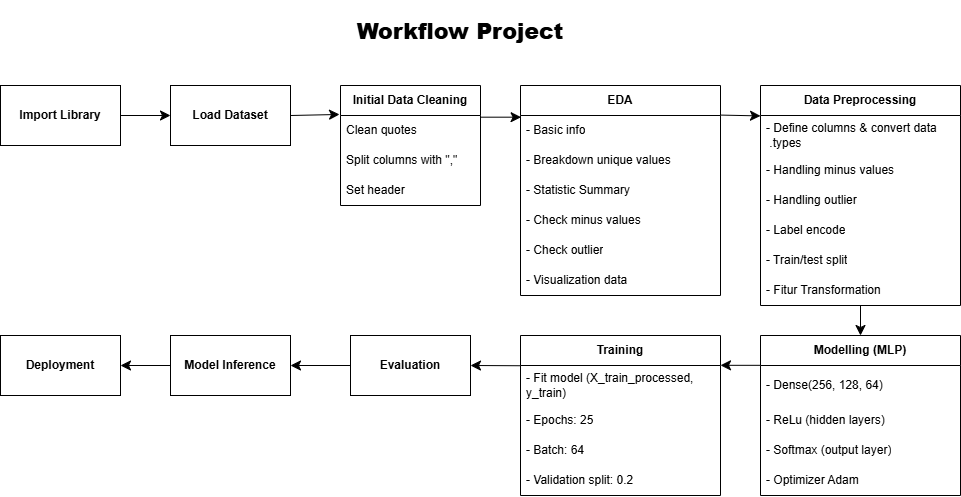

#**Import Library**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
!pip install tensorflowjs
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.11.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
db-dtypes 1.4.4 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.38.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


# **Load Dataset**

In [2]:
df = pd.read_csv('/content/ac-01_telco_customer_behavior_mock_data - ac-01_telco_customer_behavior_mock_data.csv')

In [3]:
df.head()

,"customer_id,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count,target_offer"
0,"C00001,Prepaid,Realme,1.5,0.8041460263450491,7..."
1,"C00002,Postpaid,Vivo,1.09,0.10768637529365216,..."
2,"C00003,Postpaid,Xiaomi,3.24,0.3138939838062413..."
3,"C00004,Prepaid,Apple,5.32,0.42015759810355613,..."
4,"C00005,Prepaid,Huawei,1.91,0.2516379006484085,..."


# **Initial Data Cleaning**

In [4]:
file_name = '/content/ac-01_telco_customer_behavior_mock_data - ac-01_telco_customer_behavior_mock_data.csv'
df_raw = pd.read_csv(file_name, header=None, encoding='utf-8-sig')
df_raw[0] = df_raw[0].str.strip('"')
df = df_raw[0].str.split(',', expand=True)
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)
df.columns = df.columns.str.strip('"')
df = df.applymap(lambda x: x.strip('"') if isinstance(x, str) else x)
df.head()

/tmp/ipython-input-3935207981.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip('"') if isinstance(x, str) else x)


,customer_id,plan_type,device_brand,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count,target_offer
0,C00001,Prepaid,Realme,1.5,0.8041460263450491,7.98,13,70000.0,4,0.2844189968419545,0,General Offer
1,C00002,Postpaid,Vivo,1.09,0.10768637529365216,9.56,9,63000.0,3,0.11508628205361705,0,General Offer
2,C00003,Postpaid,Xiaomi,3.24,0.31389398380624134,4.61,13,89000.0,7,0.40299759641160643,0,General Offer
3,C00004,Prepaid,Apple,5.32,0.42015759810355613,6.96,8,67000.0,4,0.3021685393268597,0,General Offer
4,C00005,Prepaid,Huawei,1.91,0.2516379006484085,11.01,21,72000.0,5,0.4879106397322117,0,General Offer


# **Exploratory Data Analysis (EDA)**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        10000 non-null  object
 1   plan_type          10000 non-null  object
 2   device_brand       10000 non-null  object
 3   avg_data_usage_gb  10000 non-null  object
 4   pct_video_usage    10000 non-null  object
 5   avg_call_duration  10000 non-null  object
 6   sms_freq           10000 non-null  object
 7   monthly_spend      10000 non-null  object
 8   topup_freq         10000 non-null  object
 9   travel_score       10000 non-null  object
 10  complaint_count    10000 non-null  object
 11  target_offer       10000 non-null  object
dtypes: object(12)
memory usage: 937.6+ KB


In [6]:
df.isnull().sum()

,0
0,
customer_id,0
plan_type,0
device_brand,0
avg_data_usage_gb,0
pct_video_usage,0
avg_call_duration,0
sms_freq,0
monthly_spend,0
topup_freq,0


In [7]:
print("\n=== BREAKDOWN UNIQUE VALUES ===")

# FUNCTION UNTUK MEMPERINDAH OUTPUT
def breakdown_unique(df, column):
    print(f"\n--- {column.upper()} ---")

    # jumlah unique
    print(f"Unique count  : {df[column].nunique()}")

    # tampilkan nilai unik
    print("Unique values :", df[column].unique())

    # frekuensi tiap nilai
    print("\nFrequency:")
    print(df[column].value_counts())

# panggil fungsi untuk tiap kolom
for col in ['plan_type', 'device_brand', 'target_offer']:
    if col in df.columns:
        breakdown_unique(df, col)



=== BREAKDOWN UNIQUE VALUES ===

--- PLAN_TYPE ---
Unique count  : 2
Unique values : ['Prepaid' 'Postpaid']

Frequency:
plan_type
Prepaid     6108
Postpaid    3892
Name: count, dtype: int64

--- DEVICE_BRAND ---
Unique count  : 7
Unique values : ['Realme' 'Vivo' 'Xiaomi' 'Apple' 'Huawei' 'Oppo' 'Samsung']

Frequency:
device_brand
Realme     1509
Xiaomi     1458
Samsung    1439
Huawei     1438
Vivo       1395
Apple      1386
Oppo       1375
Name: count, dtype: int64

--- TARGET_OFFER ---
Unique count  : 9
Unique values : ['General Offer' 'Top-up Promo' 'Device Upgrade Offer' 'Data Booster'
 'Retention Offer' 'Streaming Partner Pack' 'Roaming Pass' 'Voice Bundle'
 'Family Plan Offer']

Frequency:
target_offer
General Offer             6070
Device Upgrade Offer      1502
Data Booster               797
Retention Offer            761
Top-up Promo               370
Streaming Partner Pack     258
Roaming Pass                93
Family Plan Offer           81
Voice Bundle                68
Nam

In [8]:
# list kolom numerik
numeric_cols = ['avg_data_usage_gb','pct_video_usage','avg_call_duration',
                'sms_freq','monthly_spend','topup_freq','travel_score','complaint_count']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

 #summary statistik(numerik)
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
avg_data_usage_gb,10000.0,5.958883,4.192909,0.030000,2.870000,4.990000,8.040000,39.020000
pct_video_usage,10000.0,0.402639,0.195741,0.000000,0.265290,0.400116,0.535161,1.000000
avg_call_duration,10000.0,9.971357,4.954993,-8.370000,6.650000,10.020000,13.320000,27.770000
sms_freq,10000.0,15.010800,3.872775,4.000000,12.000000,15.000000,18.000000,31.000000
monthly_spend,10000.0,109776.500000,46237.321903,-13000.000000,78000.000000,102000.000000,135000.000000,450000.000000
topup_freq,10000.0,2.986600,1.709828,0.000000,2.000000,3.000000,4.000000,12.000000
travel_score,10000.0,0.282441,0.158366,0.003376,0.158775,0.261206,0.385656,0.854814
complaint_count,10000.0,0.492600,0.704127,0.000000,0.000000,0.000000,1.000000,5.000000


In [9]:
# deteksi nilai negatif
for col in numeric_cols:
    neg_rows = df[df[col] < 0]

    if len(neg_rows) > 0:
        print(f"\nKolom: {col}")
        print(f"Jumlah nilai negatif ditemukan: {len(neg_rows)}")

        display(
            neg_rows[["customer_id", col]].head(10)
        )



Kolom: avg_call_duration
Jumlah nilai negatif ditemukan: 229


,customer_id,avg_call_duration
16,C00017,-0.26
55,C00056,-1.69
117,C00118,-4.28
137,C00138,-0.34
198,C00199,-2.20
240,C00241,-0.43
289,C00290,-1.42
324,C00325,-1.13
373,C00374,-6.45
382,C00383,-6.73



Kolom: monthly_spend
Jumlah nilai negatif ditemukan: 2


,customer_id,monthly_spend
2197,C02198,-13000.0
2244,C02245,-6000.0


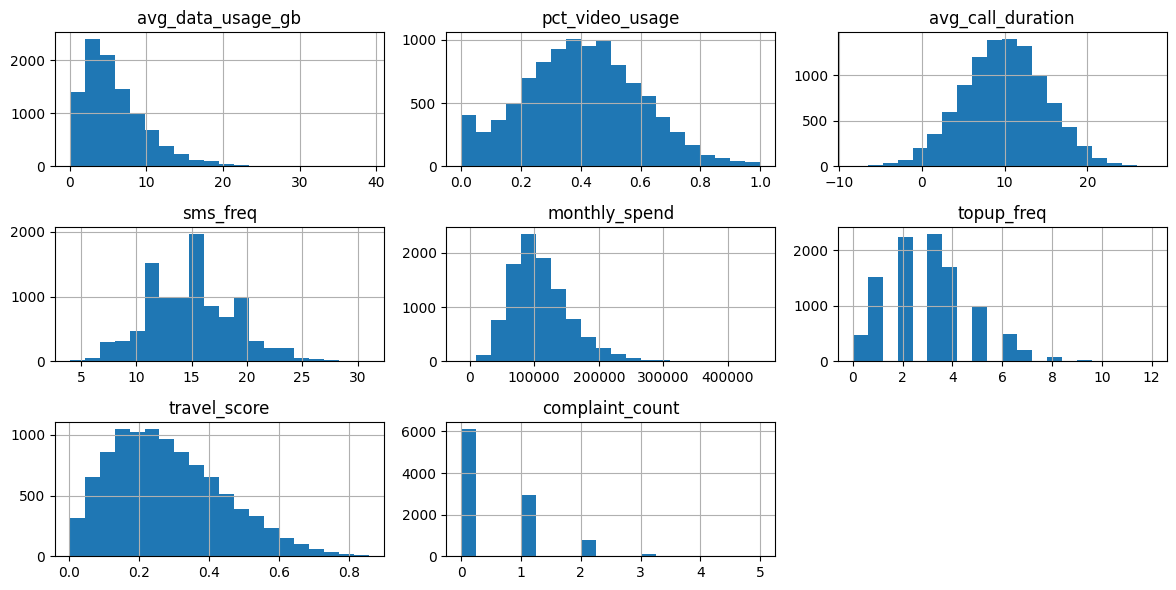

In [10]:
#histogram kolom numerik
df[numeric_cols].hist(bins=20, figsize=(12,6))
plt.tight_layout()
plt.show()

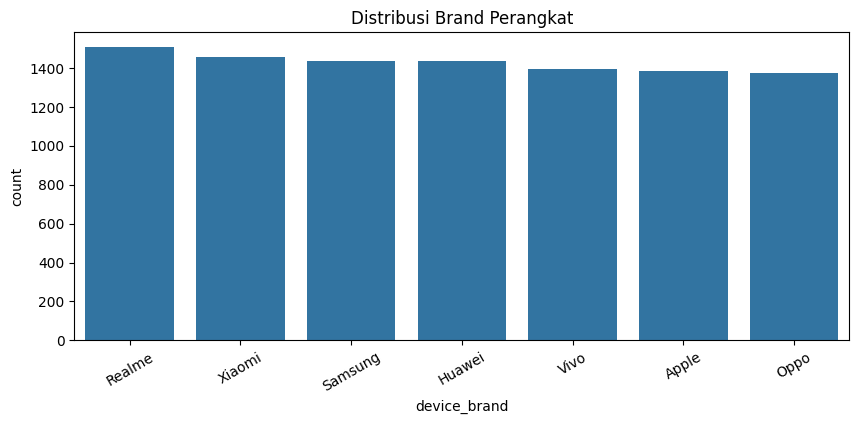

In [11]:
#distribusi brand hp
plt.figure(figsize=(10,4))
sns.countplot(x=df['device_brand'], order=df['device_brand'].value_counts().index)
plt.title("Distribusi Brand Perangkat")
plt.xticks(rotation=30)
plt.show()

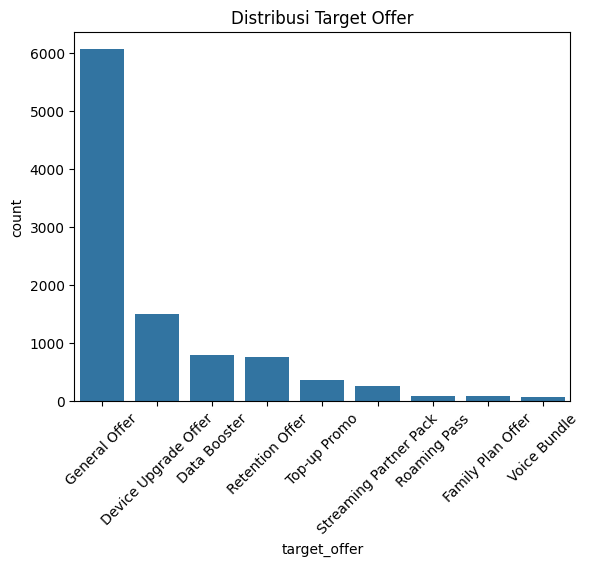

In [12]:
#plt.figure(figsize=(12,4))
sns.countplot(x=df['target_offer'], order=df['target_offer'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribusi Target Offer")
plt.show()

In [13]:
# cek outlier metode iqr
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_summary[col] = len(outliers)

outlier_summary

{'avg_data_usage_gb': 305,
 'pct_video_usage': 40,
 'avg_call_duration': 72,
 'sms_freq': 17,
 'monthly_spend': 250,
 'topup_freq': 110,
 'travel_score': 70,
 'complaint_count': 138}

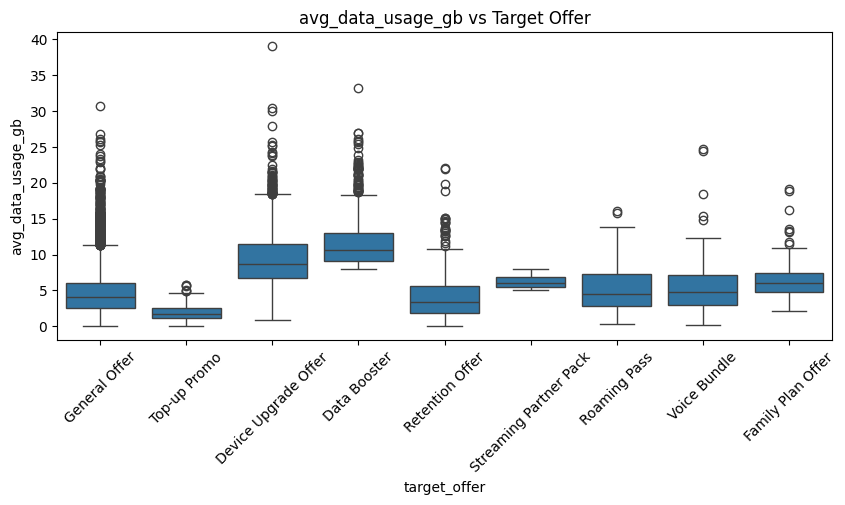

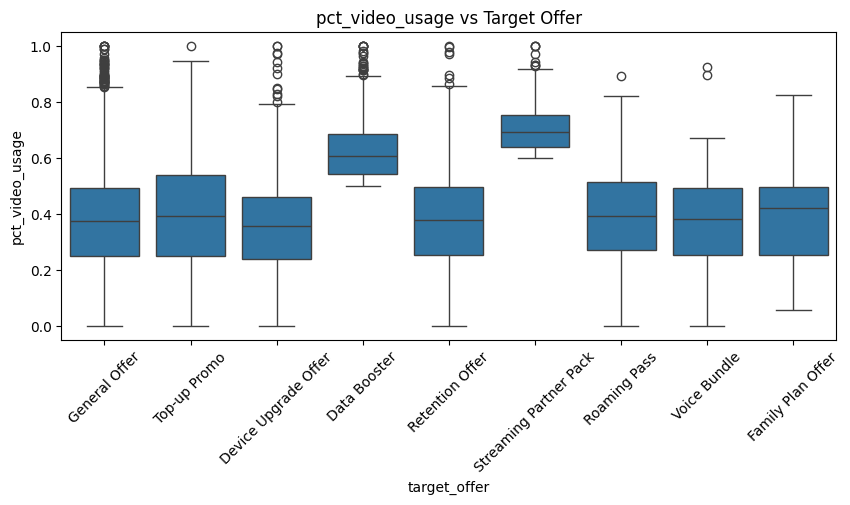

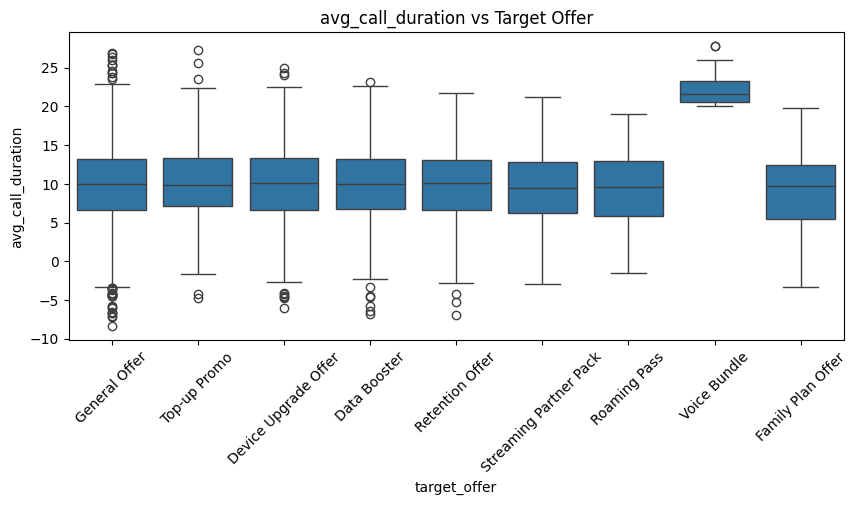

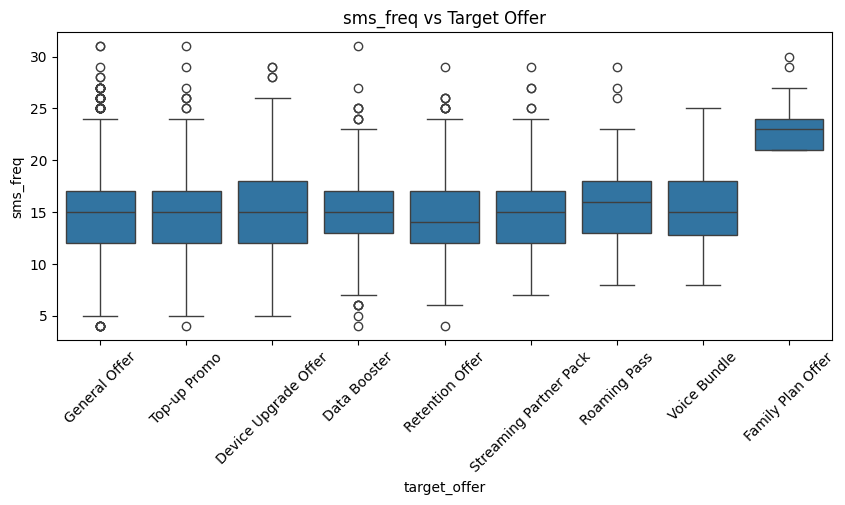

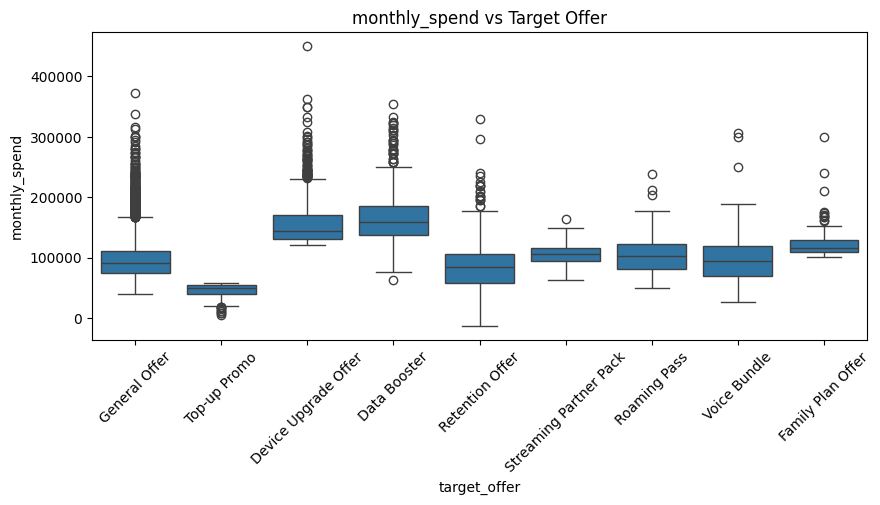

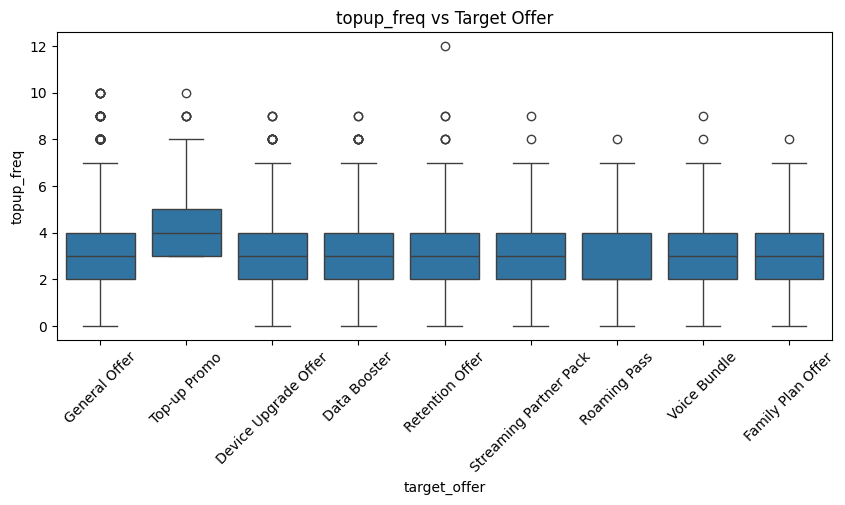

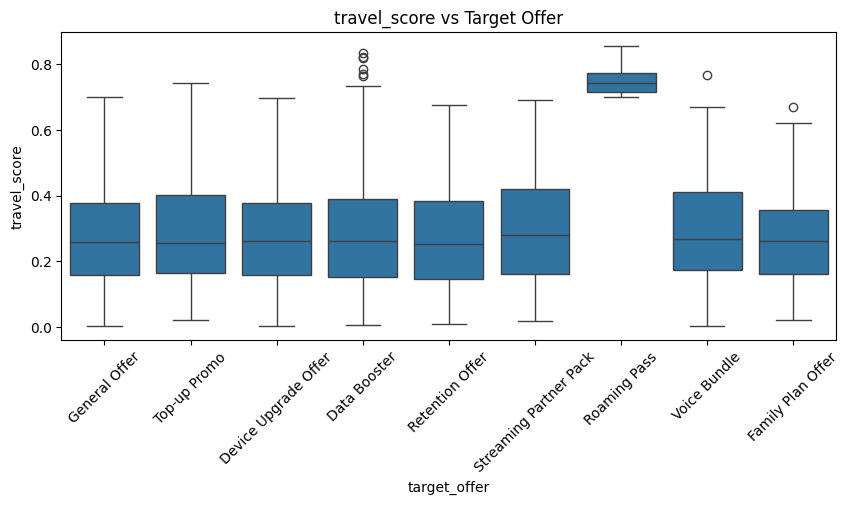

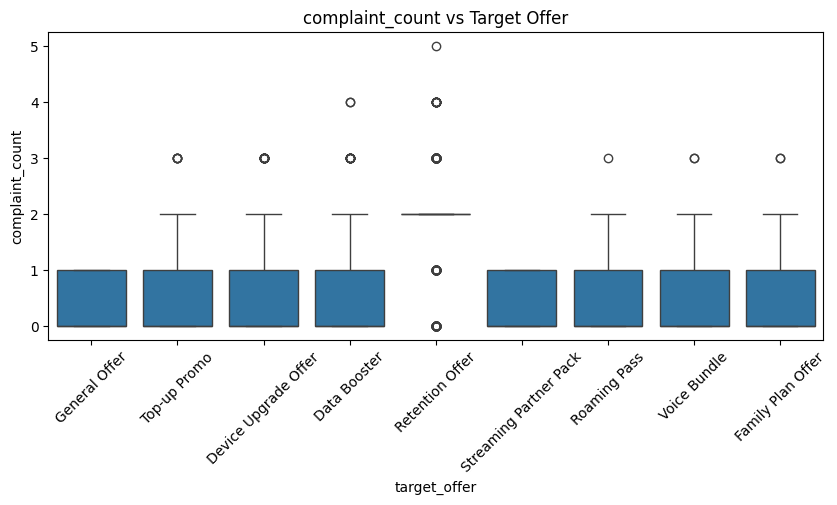

In [14]:
#boxplot fitur numerik vs target offer
for col in numeric_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=df['target_offer'], y=df[col])
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Target Offer")
    plt.show()

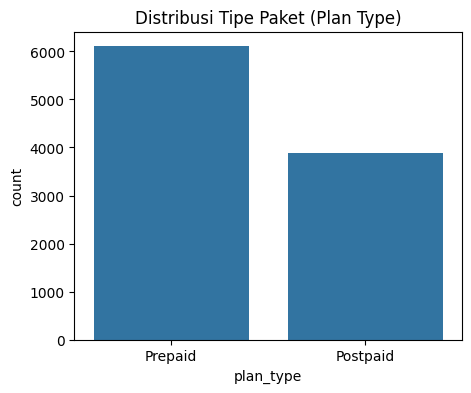

In [15]:
plt.figure(figsize=(5,4))
sns.countplot(x=df['plan_type'])
plt.title("Distribusi Tipe Paket (Plan Type)")
plt.show()

# **Data Preprocessing**

In [16]:
numeric_cols = [
    "avg_data_usage_gb",
    "pct_video_usage",
    "avg_call_duration",
    "sms_freq",
    "monthly_spend",
    "topup_freq",
    "travel_score",
    "complaint_count"
]

df[numeric_cols] = df[numeric_cols].astype(float)

categorical_cols = ["plan_type", "device_brand"]

target_col = "target_offer"

In [17]:
#replace nilai negatif dengan mean
#df_fixed_mean = df.copy()  # backup

#for col in numeric_cols:
    # hitung mean hanya dari nilai yang valid (>= 0)
    #valid_mean = df_fixed_mean[df_fixed_mean[col] >= 0][col].mean()

    # replace
    #df_fixed_mean.loc[df_fixed_mean[col] < 0, col] = valid_mean

#df_fixed_mean.describe()

In [18]:
# konvert nilai negatif menjadi absolute
df_fixed_abs = df.copy()  # backup lain

for col in numeric_cols:
    df_fixed_abs[col] = df_fixed_abs[col].abs()

df_fixed_abs.describe()

,avg_data_usage_gb,pct_video_usage,avg_call_duration,sms_freq,monthly_spend,topup_freq,travel_score,complaint_count
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.958883,0.402639,10.054877,15.010800,109780.300000,2.986600,0.282441,0.492600
std,4.192909,0.195741,4.783220,3.872775,46228.298016,1.709828,0.158366,0.704127
min,0.030000,0.000000,0.010000,4.000000,2000.000000,0.000000,0.003376,0.000000
25%,2.870000,0.265290,6.660000,12.000000,78000.000000,2.000000,0.158775,0.000000
50%,4.990000,0.400116,10.020000,15.000000,102000.000000,3.000000,0.261206,0.000000
75%,8.040000,0.535161,13.320000,18.000000,135000.000000,4.000000,0.385656,1.000000
max,39.020000,1.000000,27.770000,31.000000,450000.000000,12.000000,0.854814,5.000000


In [19]:
#handling outlier dengan Capping
df_cap = df_fixed_abs.copy()

for col in numeric_cols:
    Q1 = df_cap[col].quantile(0.25)
    Q3 = df_cap[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_cap[col] = np.where(
        df_cap[col] < lower_bound, lower_bound,
        np.where(df_cap[col] > upper_bound, upper_bound, df_cap[col])
    )

In [20]:
df_clean = df_cap.copy()

In [21]:
# label encoding target
label_enc = LabelEncoder()
df_clean["target_offer_encoded"] = label_enc.fit_transform(df_clean[target_col])

In [22]:
# pembagian data train test split
X = df_clean[categorical_cols + numeric_cols]
y = df_clean["target_offer_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 8000, Test size: 2000


In [23]:
#fitur transformation
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# **Modelling**

In [24]:
input_dim = X_train_processed.shape[1]
num_classes = len(label_enc.classes_)

model = Sequential([
    tf.keras.Input(shape=(input_dim,)),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,345 (181.04 KB)

 Trainable params: 46,345 (181.04 KB)

 Non-trainable params: 0 (0.00 B)

# **Training**

In [25]:
history = model.fit(
    X_train_processed, y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5699 - loss: 1.3708 - val_accuracy: 0.7894 - val_loss: 0.6619
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8029 - loss: 0.6318 - val_accuracy: 0.8419 - val_loss: 0.4565
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8353 - loss: 0.4870 - val_accuracy: 0.8562 - val_loss: 0.3909
Epoch 4/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8536 - loss: 0.4164 - val_accuracy: 0.8863 - val_loss: 0.3179
Epoch 5/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8664 - loss: 0.3782 - val_accuracy: 0.8813 - val_loss: 0.3022
Epoch 6/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8715 - loss: 0.3484 - val_accuracy: 0.8944 - val_loss: 0.2650
Epoch 7/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8762 - loss: 0.3190 - val_accuracy: 0.8975 - val_loss: 0.2484
Epoch 8/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8861 - loss: 0.3033 - val_accuracy: 0

# **Evaluate**

In [26]:
# prediksi label dari test set
y_pred_probs = model.predict(X_test_processed)
y_pred = np.argmax(y_pred_probs, axis=1)

# classification report
class_names = label_enc.classes_
print(classification_report(y_test, y_pred, target_names=class_names))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
                        precision    recall  f1-score   support

          Data Booster       0.84      0.99      0.90       159
  Device Upgrade Offer       0.98      0.91      0.94       300
     Family Plan Offer       1.00      0.19      0.32        16
         General Offer       0.96      0.98      0.97      1214
       Retention Offer       0.93      0.93      0.93       152
          Roaming Pass       0.67      0.11      0.18        19
Streaming Partner Pack       0.84      0.73      0.78        52
          Top-up Promo       0.84      0.91      0.87        74
          Voice Bundle       0.67      0.57      0.62        14

              accuracy                           0.94      2000
             macro avg       0.86      0.70      0.72      2000
          weighted avg       0.94      0.94      0.93      2000



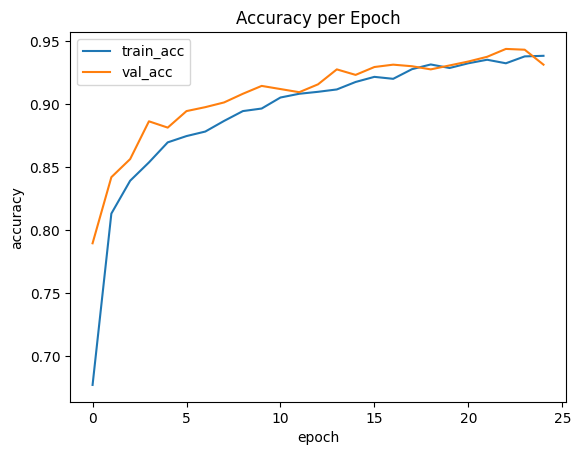

In [27]:
# akurasi
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy per Epoch')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

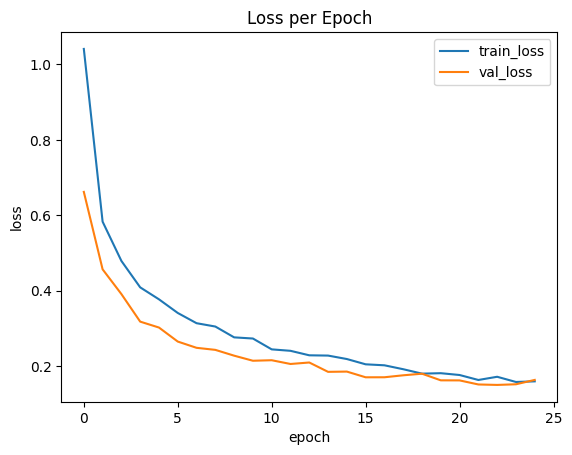

In [28]:
#loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss per Epoch')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

# **Model Inference**

In [29]:
def rekomendasi_top3(user_row):
    # ubah input user ke format model
    X_input = preprocessor.transform(pd.DataFrame([user_row]))

    pred = model.predict(X_input)[0]

    # top 3 probabilitas tertinggi
    top3_idx = pred.argsort()[-3:][::-1]

    #mapping class
    hasil = [(label_enc.inverse_transform([idx])[0], round(pred[idx], 4)) for idx in top3_idx]
    return hasil

In [30]:
contoh_1 = {
    "plan_type": "Prepaid",
    "device_brand": "Oppo",
    "avg_data_usage_gb": 5.1,
    "pct_video_usage": 0.41,
    "avg_call_duration": 8.9,
    "sms_freq": 14,
    "monthly_spend": 82000,
    "topup_freq": 4,
    "travel_score": 0.22,
    "complaint_count": 0
}

print("\nRekomendasi Top-3 Produk:")
for idx, (offer, score) in enumerate(rekomendasi_top3(contoh_1), start=1):
    print(f"{idx}. {offer}")


Rekomendasi Top-3 Produk:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1. General Offer
2. Top-up Promo
3. Retention Offer


In [31]:
contoh_2 = {
    "plan_type": "Postpaid",
    "device_brand": "Samsung",
    "avg_data_usage_gb": 15.4,
    "pct_video_usage": 0.76,
    "avg_call_duration": 3.5,
    "sms_freq": 2,
    "monthly_spend": 190000,
    "topup_freq": 1,
    "travel_score": 0.33,
    "complaint_count": 2
}
print("\nRekomendasi Top-3 Produk:")
for idx, (offer, score) in enumerate(rekomendasi_top3(contoh_2), start=1):
    print(f"{idx}. {offer}")


Rekomendasi Top-3 Produk:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1. Data Booster
2. Device Upgrade Offer
3. Voice Bundle


# **Deployment**

In [32]:
model.save("rekomendasi_model.h5")

In [33]:
model.save("rekomendasi_model.keras")

In [34]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(label_enc, "label_encoder.pkl")

['label_encoder.pkl']

In [35]:
!tensorflowjs_converter --input_format=keras rekomendasi_model.h5 tfjs_model


2025-12-02 10:11:16.800277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764670276.825978    1106 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764670276.833674    1106 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764670276.852538    1106 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764670276.852584    1106 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764670276.852589    1106 computation_placer.cc:177] computation placer alr

In [36]:
!pip freeze > requirements.txt

In [37]:
!apt-get install git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.15).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [38]:
!git config --global user.name "bellata21"
!git config --global user.email "andhinibellatri@gmail.com"

In [ ]:
!mkdir telco-ml-model
!cp -r trained_model.keras preprocessor.pkl label_encoder.pkl requirements.txt telco-ml-model/